In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [54]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler

In [55]:
base_data = pd.read_csv('C:/Users/TOLGA/Downloads/playground-series-s5e10/train.csv')
test_data = pd.read_csv('C:/Users/TOLGA/Downloads/playground-series-s5e10/test.csv')

In [56]:
base_data.head(15)

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
5,5,highway,3,0.54,70,night,foggy,True,False,morning,False,True,0,0.61
6,6,highway,1,0.04,45,night,foggy,False,True,morning,True,False,2,0.20
7,7,highway,2,0.33,45,daylight,clear,False,True,evening,False,True,0,0.16
8,8,rural,3,0.63,25,dim,clear,True,False,evening,True,True,2,0.18
9,9,urban,4,0.38,45,dim,clear,True,True,afternoon,True,True,2,0.15


In [57]:
base_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [58]:
base_data.describe()

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377
std,149462.849974,1.120434,0.272563,15.788521,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000


In [59]:
base_data.shape

(517754, 14)

517 thousand 754 rows
13 features(13 independent variables/features) , 1 dependent/target variable

In [61]:
base_data.dtypes

id                          int64
road_type                  object
num_lanes                   int64
curvature                 float64
speed_limit                 int64
lighting                   object
weather                    object
road_signs_present           bool
public_road                  bool
time_of_day                object
holiday                      bool
school_season                bool
num_reported_accidents      int64
accident_risk             float64
dtype: object

In [62]:
base_data.tail(10)

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
517744,517744,highway,4,0.38,60,night,clear,True,False,afternoon,True,False,1,0.42
517745,517745,highway,4,0.02,35,daylight,clear,True,True,morning,False,False,0,0.02
517746,517746,rural,4,0.53,70,dim,rainy,True,True,evening,False,False,3,0.53
517747,517747,urban,3,0.39,35,dim,foggy,True,True,morning,False,False,0,0.15
517748,517748,rural,2,0.53,70,dim,foggy,True,True,afternoon,True,True,2,0.37
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51
517753,517753,highway,2,0.31,45,dim,rainy,False,True,afternoon,True,True,2,0.22


In [63]:
base_data.value_counts('weather')

weather
foggy    181463
clear    179306
rainy    156985
Name: count, dtype: int64

In [64]:
base_data.value_counts('num_reported_accidents')

num_reported_accidents
1    209674
2    145965
0    125269
3     34197
4      2392
5       231
6        24
7         2
Name: count, dtype: int64

In [65]:
base_data.value_counts('lighting')

lighting
dim         183826
daylight    178015
night       155913
Name: count, dtype: int64

In [66]:
base_data.value_counts('num_lanes')

num_lanes
1    131168
2    130054
4    129118
3    127414
Name: count, dtype: int64

In [67]:
base_data.value_counts('road_type')

road_type
highway    173672
rural      172719
urban      171363
Name: count, dtype: int64

In [68]:
base_data.nunique()

id                        517754
road_type                      3
num_lanes                      4
curvature                    261
speed_limit                    5
lighting                       3
weather                        3
road_signs_present             2
public_road                    2
time_of_day                    3
holiday                        2
school_season                  2
num_reported_accidents         8
accident_risk                 98
dtype: int64

In [69]:
base_data.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [70]:
LE = LabelEncoder()
OHE = OneHotEncoder()
SC = StandardScaler()

In [71]:
y = base_data.pop('accident_risk')

In [72]:
y

0         0.13
1         0.35
2         0.30
3         0.21
4         0.56
          ... 
517749    0.32
517750    0.26
517751    0.19
517752    0.51
517753    0.22
Name: accident_risk, Length: 517754, dtype: float64

In [73]:
X = base_data.copy()

In [74]:
base_data['curvature'].mean()

0.4887191965740487

In [75]:
base_data['curvature'].std()

0.2725632502134713

In [76]:
base_data['curvature'].var()

0.07429072536693133

In [77]:
base_data.pop('id')

0              0
1              1
2              2
3              3
4              4
           ...  
517749    517749
517750    517750
517751    517751
517752    517752
517753    517753
Name: id, Length: 517754, dtype: int64

In [78]:
base_data.head(12)

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1
5,highway,3,0.54,70,night,foggy,True,False,morning,False,True,0
6,highway,1,0.04,45,night,foggy,False,True,morning,True,False,2
7,highway,2,0.33,45,daylight,clear,False,True,evening,False,True,0
8,rural,3,0.63,25,dim,clear,True,False,evening,True,True,2
9,urban,4,0.38,45,dim,clear,True,True,afternoon,True,True,2


Reguralization with Lasso might be useful because of the number of features that is highly correlated to target variable compared to others.

In [80]:
y.head(6)

0    0.13
1    0.35
2    0.30
3    0.21
4    0.56
5    0.61
Name: accident_risk, dtype: float64

In [81]:
X.pop('id')

0              0
1              1
2              2
3              3
4              4
           ...  
517749    517749
517750    517750
517751    517751
517752    517752
517753    517753
Name: id, Length: 517754, dtype: int64

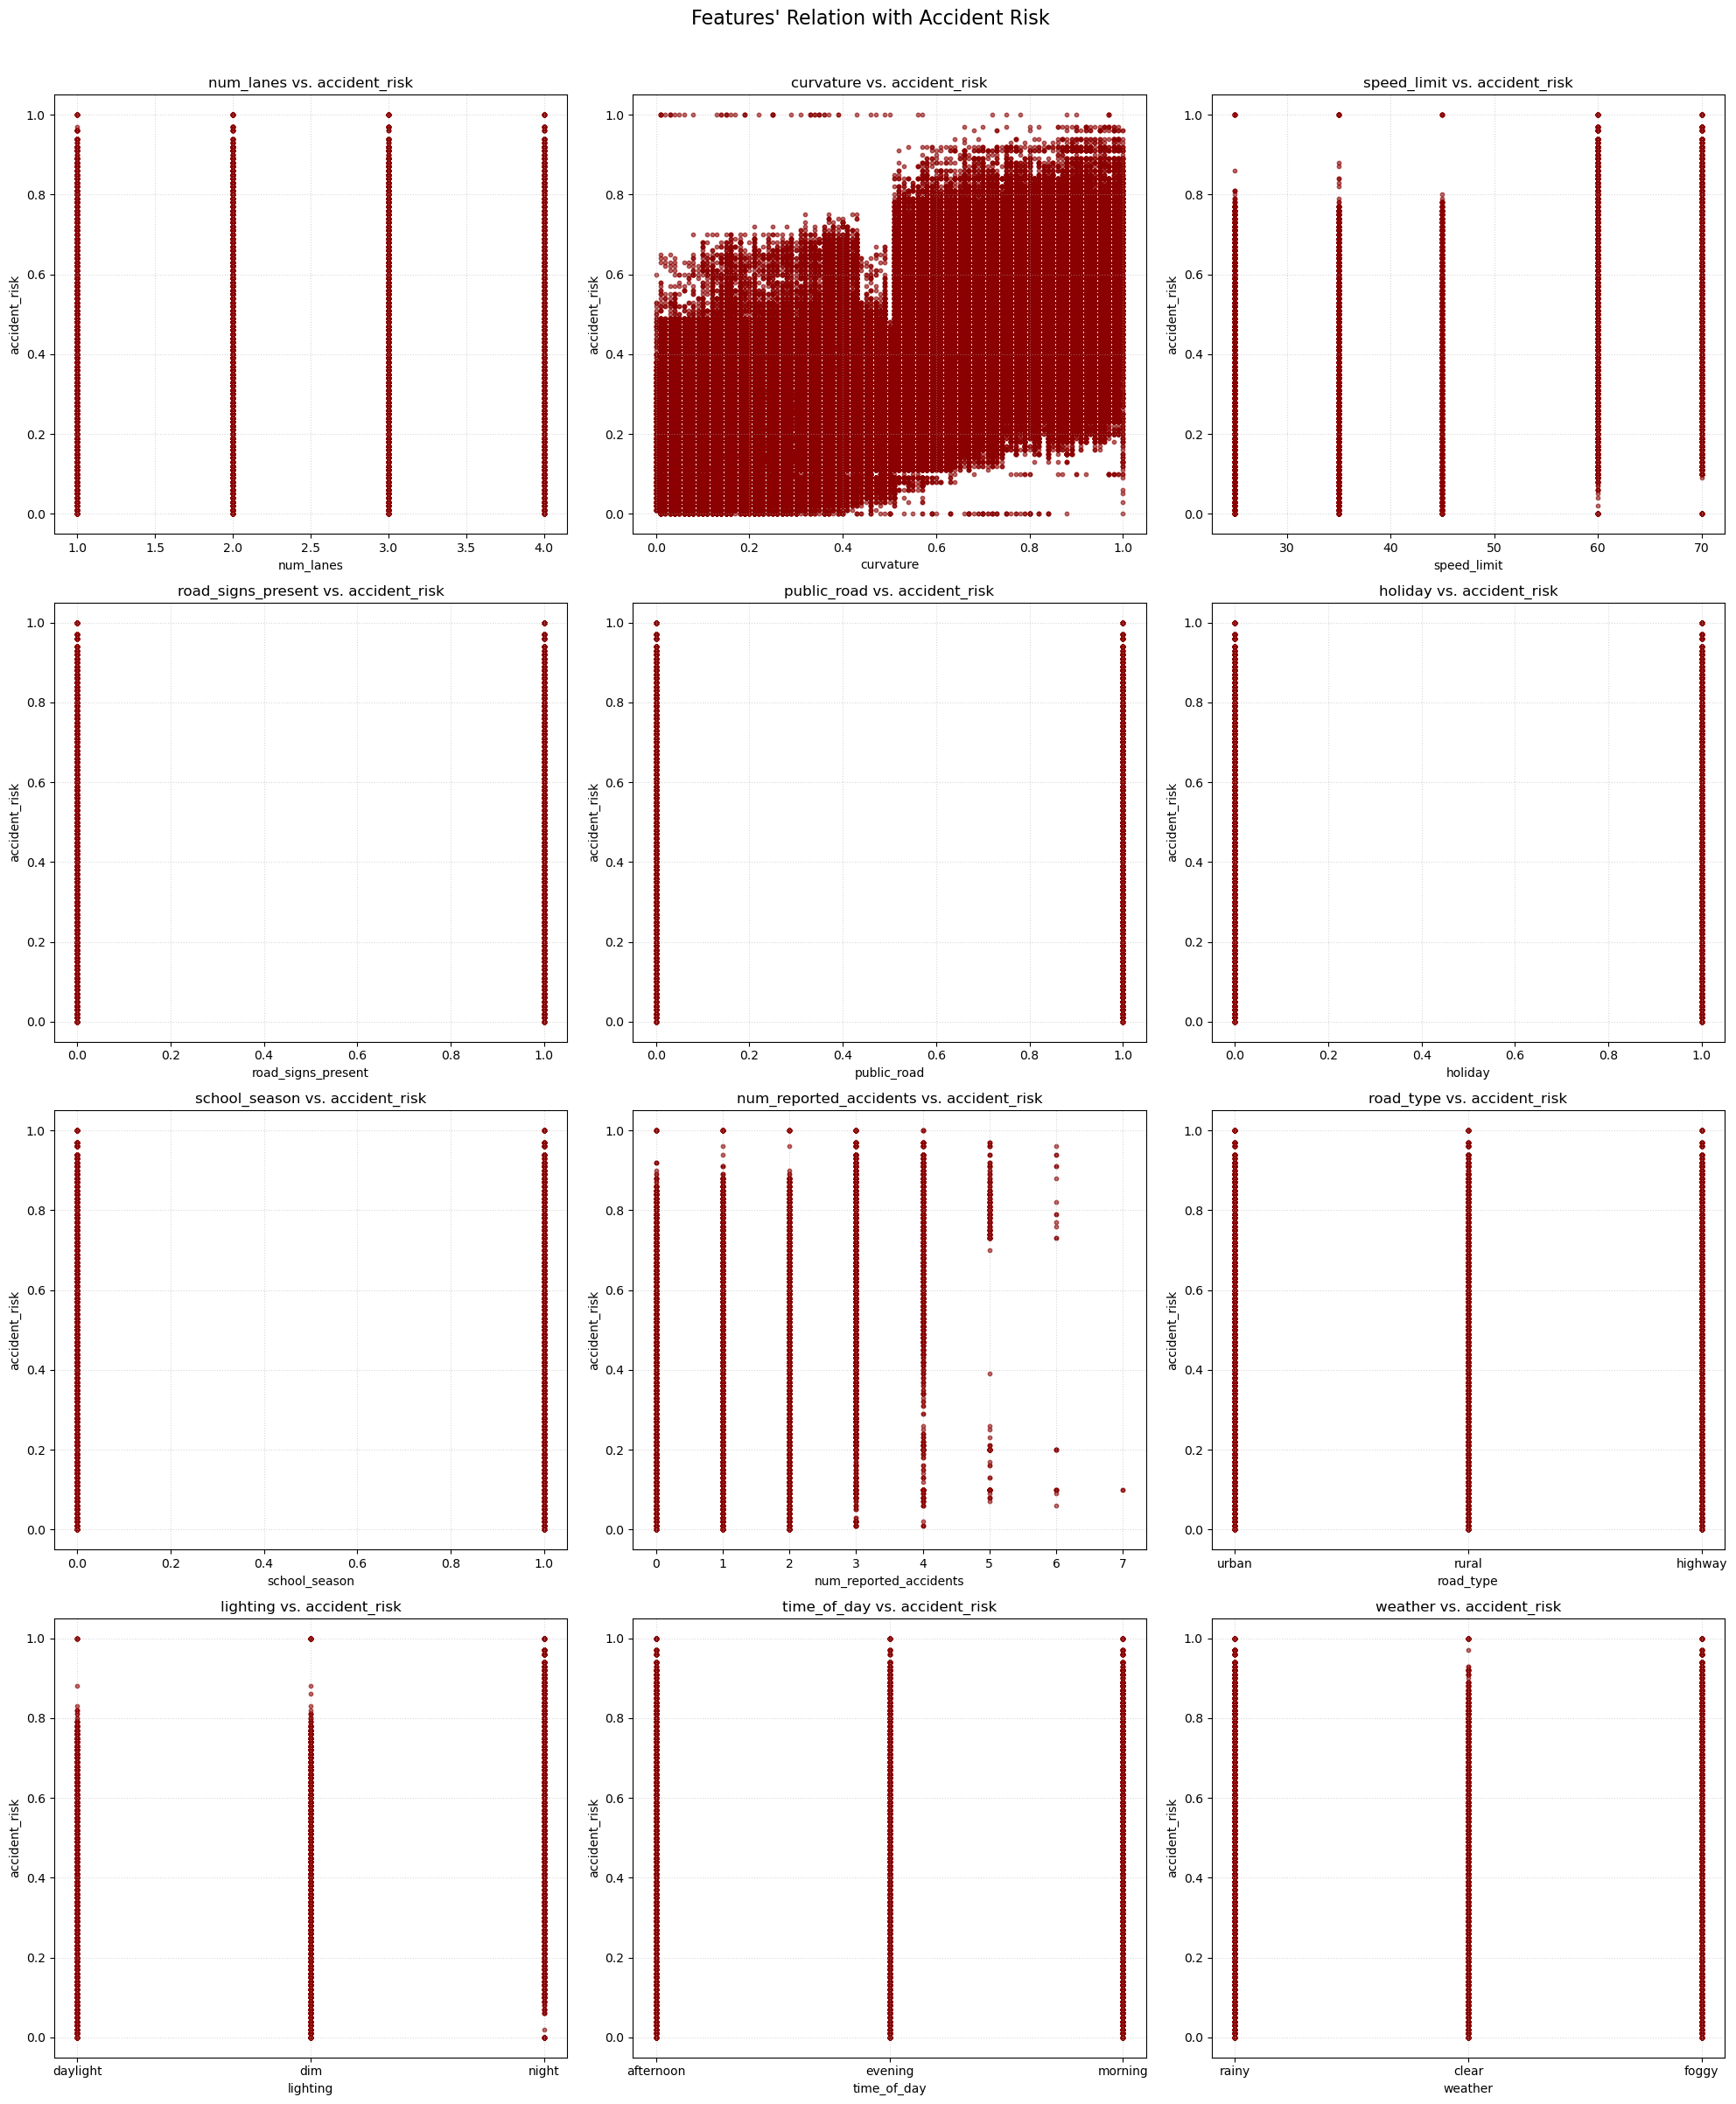

In [82]:
FEATURE_COLUMNS = [
    'num_lanes', 'curvature', 'speed_limit', 'road_signs_present', 
    'public_road', 'holiday', 'school_season', 'num_reported_accidents', 
    'road_type', 'lighting', 'time_of_day', 
    'weather'
]
num_features = len(FEATURE_COLUMNS)
rows = 4
cols = 3

fig, axs = plt.subplots(rows, cols, figsize=(20, 25)) 
axs = axs.flatten()

col_index = 0

for i, col in enumerate(FEATURE_COLUMNS):
    axs[i].scatter(X[col], y, alpha=0.6, s=10, color='darkred')
    col_index+=1
    axs[i].set_xlabel(col, fontsize=10)
    axs[i].set_ylabel('accident_risk', fontsize=10)
    axs[i].set_title(f'{col} vs. accident_risk', fontsize=12)
    axs[i].grid(True, linestyle=':', alpha=0.5)

fig.suptitle("Features' Relation with Accident Risk", fontsize=16, y=0.99)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

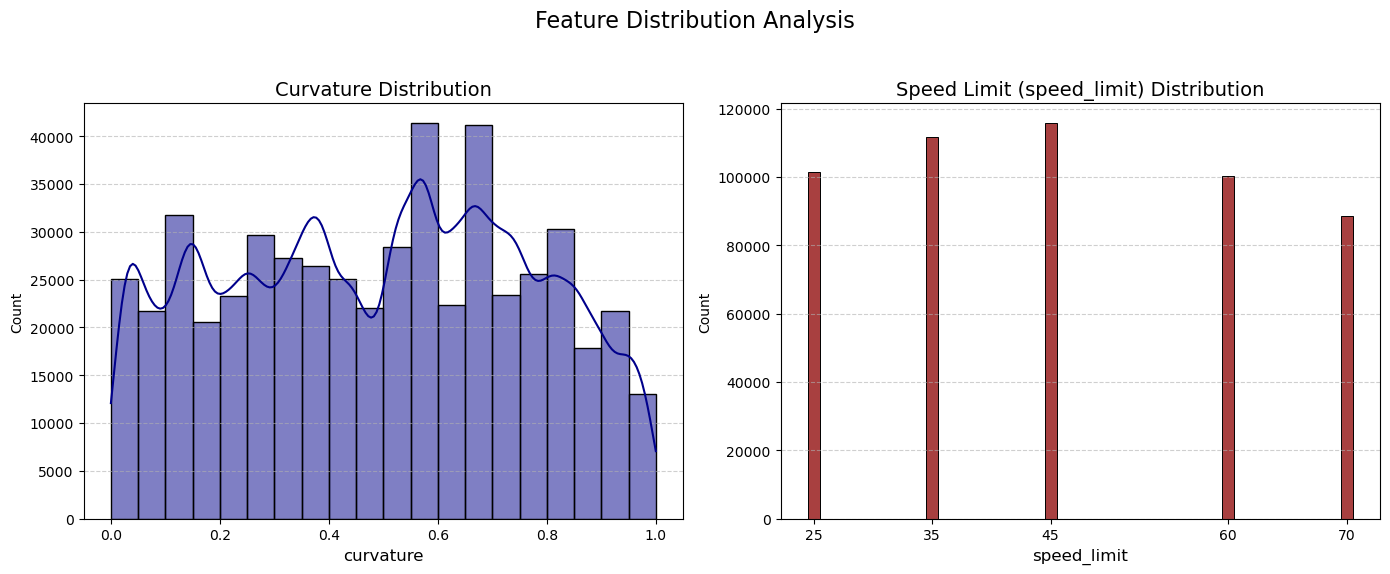

In [83]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(
    data=X, 
    x='curvature', 
    kde=True,
    ax=axs[0], 
    color='darkblue',
    bins=20
)
axs[0].set_title('Curvature Distribution', fontsize=14)
axs[0].set_xlabel('curvature', fontsize=12)
axs[0].grid(axis='y', linestyle='--', alpha=0.6)

sns.histplot(
    data=X, 
    x='speed_limit', 
    ax=axs[1], 
    color='darkred',
    bins=len(X['speed_limit'].unique()),
    discrete=True
)
axs[1].set_title('Speed Limit (speed_limit) Distribution', fontsize=14)
axs[1].set_xlabel('speed_limit', fontsize=12)
axs[1].grid(axis='y', linestyle='--', alpha=0.6)

axs[1].set_xticks(sorted(X['speed_limit'].unique()))


plt.suptitle('Feature Distribution Analysis', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

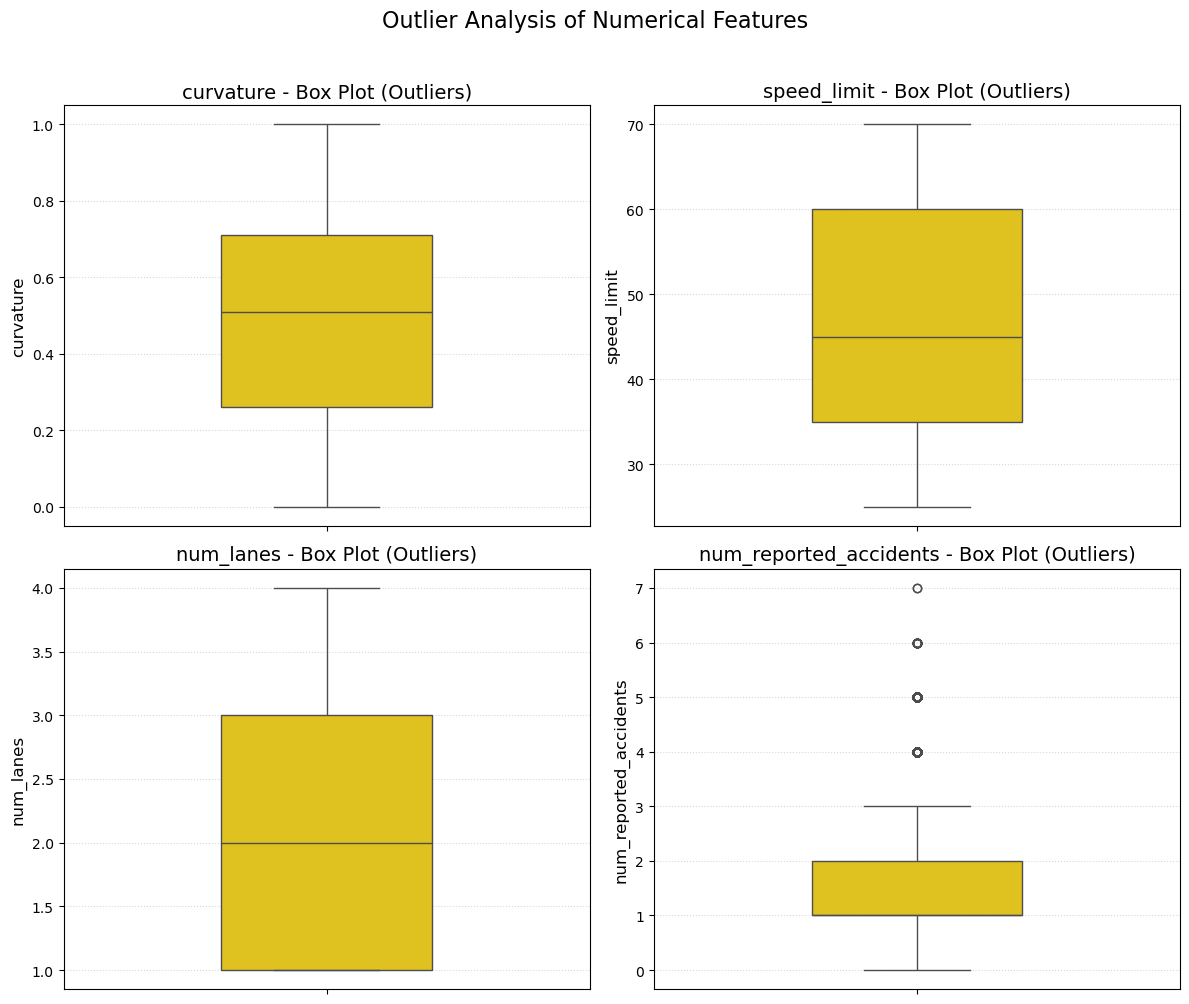

In [84]:
NUMERIC_FEATURES = ['curvature', 'speed_limit', 'num_lanes', 'num_reported_accidents']
num_features = len(NUMERIC_FEATURES)
rows = int(np.ceil(num_features / 2))
cols = 2 

fig, axs = plt.subplots(rows, cols, figsize=(12, 5 * rows)) 
axs = axs.flatten()

for i, col in enumerate(NUMERIC_FEATURES):
    # Kutu grafiği çizimi
    sns.boxplot(
        y=X[col],
        ax=axs[i],
        color='gold',
        width=0.4
    )
    
    axs[i].set_title(f'{col} - Box Plot (Outliers)', fontsize=14)
    axs[i].set_ylabel(col, fontsize=12)
    axs[i].grid(axis='y', linestyle=':', alpha=0.5)

if num_features % 2 != 0:
    fig.delaxes(axs[num_features])


plt.suptitle('Outlier Analysis of Numerical Features', fontsize=16, y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [85]:
base_data['road_type_encoded'] = LE.fit_transform(base_data ['road_type'])
base_data['time_of_day_encoded'] = LE.fit_transform(base_data['time_of_day'])
base_data['weather_encoded'] = LE.fit_transform(base_data['weather'])
base_data['lighting_encoded'] = LE.fit_transform(base_data['lighting'])

base_data['holiday'] = base_data['holiday'].astype(int)
base_data['public_road'] = base_data['public_road'].astype(int)
base_data['road_signs_present'] = base_data['road_signs_present'].astype(int)
base_data['school_season'] = base_data['school_season'].astype(int)

base_data.pop('time_of_day')
base_data.pop('weather')
base_data.pop('lighting')
base_data.pop('road_type')

0           urban
1           urban
2           rural
3         highway
4           rural
           ...   
517749    highway
517750      rural
517751      urban
517752    highway
517753    highway
Name: road_type, Length: 517754, dtype: object

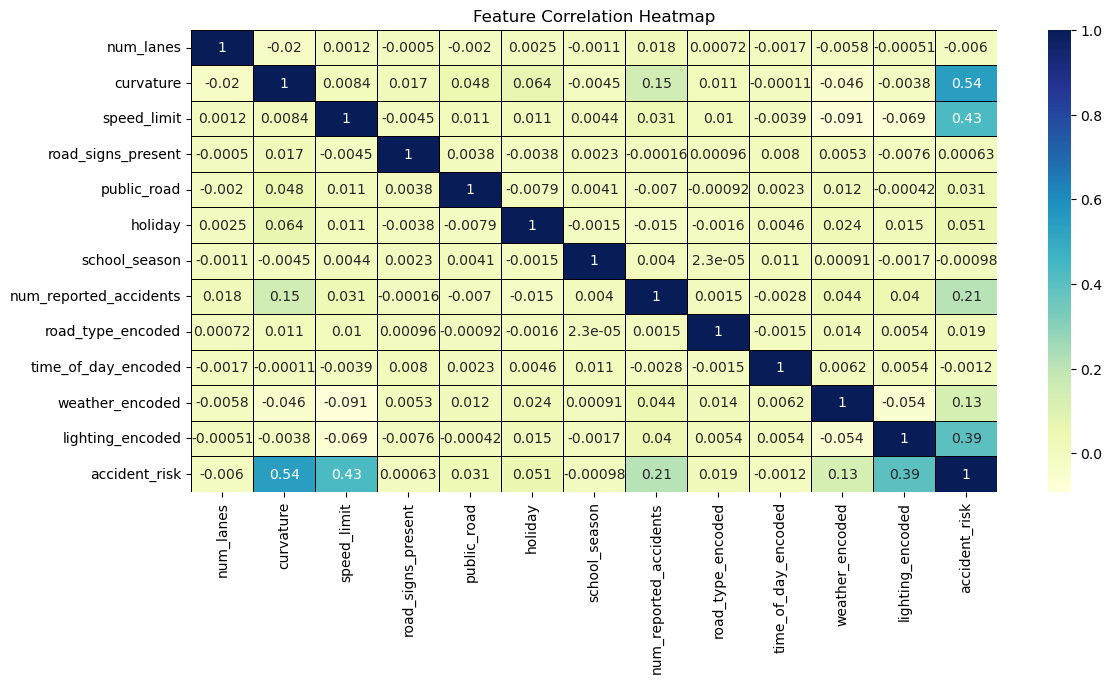

In [86]:
base_data['accident_risk'] = y

plt.figure(figsize=(13, 6))
sns.heatmap(base_data.corr(),annot=True,cmap="YlGnBu",linewidths=.5,linecolor='black',cbar=True)
plt.title('Feature Correlation Heatmap')
plt.show()


In [87]:
base_data.pop('accident_risk')

0         0.13
1         0.35
2         0.30
3         0.21
4         0.56
          ... 
517749    0.32
517750    0.26
517751    0.19
517752    0.51
517753    0.22
Name: accident_risk, Length: 517754, dtype: float64

In [88]:
test_data = pd.read_csv('C:/Users/TOLGA/Downloads/playground-series-s5e10/test.csv')

In [89]:
type(test_data)

pandas.core.frame.DataFrame

In [90]:
test_data.pop('id')

0         517754
1         517755
2         517756
3         517757
4         517758
           ...  
172580    690334
172581    690335
172582    690336
172583    690337
172584    690338
Name: id, Length: 172585, dtype: int64

In [91]:
test_data.tail(5)

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
172580,rural,2,0.01,45,dim,rainy,False,False,afternoon,True,True,2
172581,rural,1,0.74,70,daylight,foggy,False,True,afternoon,False,False,2
172582,urban,2,0.14,70,dim,clear,False,False,evening,True,True,1
172583,urban,1,0.09,45,daylight,foggy,True,True,morning,False,True,0
172584,highway,1,0.63,35,night,foggy,True,False,evening,False,False,0


In [92]:
test_data['lighting_encoded'] = LE.fit_transform(test_data['lighting'])
test_data.pop('lighting')
test_data['road_type_encoded'] = LE.fit_transform(test_data['road_type'])
test_data.pop('road_type')
test_data['weather_encoded'] = LE.fit_transform(test_data['weather'])
test_data.pop('weather')
test_data['time_of_day_encoded'] = LE.fit_transform(test_data['time_of_day'])
test_data.pop('time_of_day')
test_data.head(5)

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,lighting_encoded,road_type_encoded,weather_encoded,time_of_day_encoded
0,2,0.34,45,True,True,True,True,1,2,0,0,0
1,3,0.04,45,True,False,True,False,0,1,2,1,0
2,2,0.59,35,True,False,True,True,1,1,2,0,0
3,4,0.95,35,False,False,False,False,2,0,1,2,0
4,2,0.86,35,True,False,False,True,3,0,0,0,1


In [93]:
test_data['school_season'] = test_data['school_season'].astype(int)
test_data['holiday'] = test_data['holiday'].astype(int)
test_data['public_road'] = test_data['public_road'].astype(int)
test_data['road_signs_present'] = test_data['road_signs_present'].astype(int)
test_data.head(7)

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,lighting_encoded,road_type_encoded,weather_encoded,time_of_day_encoded
0,2,0.34,45,1,1,1,1,1,2,0,0,0
1,3,0.04,45,1,0,1,0,0,1,2,1,0
2,2,0.59,35,1,0,1,1,1,1,2,0,0
3,4,0.95,35,0,0,0,0,2,0,1,2,0
4,2,0.86,35,1,0,0,1,3,0,0,0,1
5,2,0.52,25,1,1,0,1,1,2,0,2,2
6,4,0.17,70,1,0,1,1,0,1,1,0,0


In [94]:
extracted_data = pd.DataFrame()

In [95]:
extracted_data['curvature'] = base_data['curvature']
extracted_data['speed_limit'] = base_data['speed_limit']
extracted_data['lighting_encoded'] = base_data['lighting_encoded']
extracted_data['num_reported_accidents'] = base_data['num_reported_accidents']
extracted_data['weather_encoded'] = base_data['weather_encoded']

In [329]:
extracted_data.head()

,curvature,speed_limit,lighting_encoded,num_reported_accidents,weather_encoded
0,0.06,35,0,1,2
1,0.99,35,0,0,0
2,0.63,70,1,2,0
3,0.07,35,1,1,2
4,0.58,60,0,1,1


In [97]:
accepted_values = [0,1,2]
mask = extracted_data['num_reported_accidents'].isin(accepted_values)
df_clean = extracted_data[mask].copy()

In [98]:
df_clean

,curvature,speed_limit,lighting_encoded,num_reported_accidents,weather_encoded
0,0.06,35,0,1,2
1,0.99,35,0,0,0
2,0.63,70,1,2,0
3,0.07,35,1,1,2
4,0.58,60,0,1,1
...,...,...,...,...,...
517748,0.53,70,1,2,1
517749,0.10,70,0,2,1
517750,0.47,35,0,1,2
517751,0.62,25,0,0,1


In [99]:
df_clean.head(10)

,curvature,speed_limit,lighting_encoded,num_reported_accidents,weather_encoded
0,0.06,35,0,1,2
1,0.99,35,0,0,0
2,0.63,70,1,2,0
3,0.07,35,1,1,2
4,0.58,60,0,1,1
5,0.54,70,2,0,1
6,0.04,45,2,2,1
7,0.33,45,0,0,0
8,0.63,25,1,2,0
9,0.38,45,1,2,0


In [100]:
df_clean.reset_index()

,index,curvature,speed_limit,lighting_encoded,num_reported_accidents,weather_encoded
0,0,0.06,35,0,1,2
1,1,0.99,35,0,0,0
2,2,0.63,70,1,2,0
3,3,0.07,35,1,1,2
4,4,0.58,60,0,1,1
...,...,...,...,...,...,...
480903,517748,0.53,70,1,2,1
480904,517749,0.10,70,0,2,1
480905,517750,0.47,35,0,1,2
480906,517751,0.62,25,0,0,1


In [101]:
#rfr3 = RandomForestRegressor(n_estimators=100)
#xgbr3 = XGBRegressor(n_estimators=100)

In [102]:
print("y length:",len(y))
print("df_clean length:",len(df_clean))
print("Extracted data shape:",extracted_data.shape)
print("df_clean shape:",df_clean.shape)

y length: 517754
df_clean length: 480908
Extracted data shape: (517754, 5)
df_clean shape: (480908, 5)


In [103]:
d_rows = ~extracted_data['num_reported_accidents'].isin(accepted_values)

In [104]:
reverse_mask = extracted_data[d_rows]
reverse_mask

,curvature,speed_limit,lighting_encoded,num_reported_accidents,weather_encoded
17,0.68,35,2,3,0
19,0.86,70,2,3,0
44,0.60,45,2,3,0
79,0.55,25,0,3,1
101,0.90,60,2,4,2
...,...,...,...,...,...
517735,0.84,45,2,3,1
517738,0.81,25,0,3,2
517741,0.95,35,1,3,1
517746,0.53,70,1,3,2


In [105]:
indexes = reverse_mask.index.to_list()

In [106]:
reverse_mask.iloc[17]

curvature                  0.57
speed_limit               35.00
lighting_encoded           0.00
num_reported_accidents     3.00
weather_encoded            2.00
Name: 285, dtype: float64

In [107]:
y[17]

0.51

In [108]:
y[0]

0.13

In [109]:
y2 = y.copy()
y2.drop(index=indexes, inplace=True)

In [110]:
len(y2)

480908

In [111]:
#X_train3, X_test3, y_train3, y_test3 = train_test_split(df_clean, y2, test_size=0.25, random_state=42)

In [112]:
df_clean.shape

(480908, 5)

In [113]:
df_clean = df_clean.reset_index()

In [114]:
df_clean.head(10)

,index,curvature,speed_limit,lighting_encoded,num_reported_accidents,weather_encoded
0,0,0.06,35,0,1,2
1,1,0.99,35,0,0,0
2,2,0.63,70,1,2,0
3,3,0.07,35,1,1,2
4,4,0.58,60,0,1,1
5,5,0.54,70,2,0,1
6,6,0.04,45,2,2,1
7,7,0.33,45,0,0,0
8,8,0.63,25,1,2,0
9,9,0.38,45,1,2,0


In [115]:
y2 = y2.reset_index()

In [116]:
y2.head(10)

,index,accident_risk
0,0,0.13
1,1,0.35
2,2,0.30
3,3,0.21
4,4,0.56
5,5,0.61
6,6,0.20
7,7,0.16
8,8,0.18
9,9,0.15


In [117]:
y2 = y2.drop("index",axis=1)

In [118]:
#y2 = y2.drop("index", axis=1)
y2.head(5)

,accident_risk
0,0.13
1,0.35
2,0.30
3,0.21
4,0.56


In [119]:
base_data.head()

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,road_type_encoded,time_of_day_encoded,weather_encoded,lighting_encoded
0,2,0.06,35,0,1,0,1,1,2,0,2,0
1,4,0.99,35,1,0,1,1,0,2,1,0,0
2,4,0.63,70,0,1,1,0,2,1,2,0,1
3,4,0.07,35,1,1,0,0,1,0,2,2,1
4,1,0.58,60,0,0,1,0,1,1,1,1,0


In [120]:
from sklearn.linear_model import Lasso

In [121]:
base_data.head()

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,road_type_encoded,time_of_day_encoded,weather_encoded,lighting_encoded
0,2,0.06,35,0,1,0,1,1,2,0,2,0
1,4,0.99,35,1,0,1,1,0,2,1,0,0
2,4,0.63,70,0,1,1,0,2,1,2,0,1
3,4,0.07,35,1,1,0,0,1,0,2,2,1
4,1,0.58,60,0,0,1,0,1,1,1,1,0


In [122]:
base_data.shape

(517754, 12)

In [123]:
y.shape

(517754,)

In [124]:
base_data.columns

Index(['num_lanes', 'curvature', 'speed_limit', 'road_signs_present',
       'public_road', 'holiday', 'school_season', 'num_reported_accidents',
       'road_type_encoded', 'time_of_day_encoded', 'weather_encoded',
       'lighting_encoded'],
      dtype='object')

In [125]:
f1 = base_data['curvature']/base_data['num_lanes']

In [126]:
f1

0         0.0300
1         0.2475
2         0.1575
3         0.0175
4         0.5800
           ...  
517749    0.0250
517750    0.1175
517751    0.1550
517752    0.2100
517753    0.1550
Length: 517754, dtype: float64

In [127]:
concat_data = base_data

In [128]:
concat_data['curvature_risk'] = concat_data['curvature']/concat_data['num_lanes']

In [129]:
# Koşulları tanımlama
conditions = [
    # Koşul 1: Çok Yüksek Risk (Yağmur/Sis VE Gece)
    ((concat_data['weather_encoded'].isin([1, 2])) & (concat_data['lighting_encoded'] == 2)),
    
    # Koşul 2: Yüksek Risk (Yağmur/Sis VE Loş)
    ((concat_data['weather_encoded'].isin([1, 2])) & (concat_data['lighting_encoded'] == 1)),
    
    # Koşul 3: Sadece Sis/Yağmur VEYA Sadece Gece
    ((concat_data['weather_encoded'].isin([1, 2])) | (concat_data['lighting_encoded'] == 2))
]

# Her koşul için atanacak değerler
choices = [3, 2, 1]

# np.select kullanarak yeni özelliği oluşturma
# Varsayılan değer (default=0) Düşük Risktir (Açık hava ve Gündüz)
concat_data['Visibility_Risk_Score'] = np.select(conditions, choices, default=0)

print("Yeni özellik eklenmiş veri çerçevesi:")
print(concat_data[['weather_encoded', 'lighting_encoded', 'Visibility_Risk_Score']].head(7))

Yeni özellik eklenmiş veri çerçevesi:
   weather_encoded  lighting_encoded  Visibility_Risk_Score
0                2                 0                      1
1                0                 0                      0
2                0                 1                      0
3                2                 1                      2
4                1                 0                      1
5                1                 2                      3
6                1                 2                      3


In [130]:
concat_data.head()

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,road_type_encoded,time_of_day_encoded,weather_encoded,lighting_encoded,curvature_risk,Visibility_Risk_Score
0,2,0.06,35,0,1,0,1,1,2,0,2,0,0.0300,1
1,4,0.99,35,1,0,1,1,0,2,1,0,0,0.2475,0
2,4,0.63,70,0,1,1,0,2,1,2,0,1,0.1575,0
3,4,0.07,35,1,1,0,0,1,0,2,2,1,0.0175,2
4,1,0.58,60,0,0,1,0,1,1,1,1,0,0.5800,1


In [131]:
concat_data['speed_per_lane'] = concat_data['speed_limit'] / concat_data['num_lanes']

In [132]:
concat_data['active_school_day'] = np.where((concat_data['school_season'] == 1) & (concat_data['holiday'] == 0),1,0)

In [133]:
concat_data['density_risk_score'] = (concat_data['speed_per_lane'] * (concat_data['curvature'] + 1))

In [134]:
concat_data.head()

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,road_type_encoded,time_of_day_encoded,weather_encoded,lighting_encoded,curvature_risk,Visibility_Risk_Score,speed_per_lane,active_school_day,density_risk_score
0,2,0.06,35,0,1,0,1,1,2,0,2,0,0.0300,1,17.50,1,18.5500
1,4,0.99,35,1,0,1,1,0,2,1,0,0,0.2475,0,8.75,0,17.4125
2,4,0.63,70,0,1,1,0,2,1,2,0,1,0.1575,0,17.50,0,28.5250
3,4,0.07,35,1,1,0,0,1,0,2,2,1,0.0175,2,8.75,0,9.3625
4,1,0.58,60,0,0,1,0,1,1,1,1,0,0.5800,1,60.00,0,94.8000


In [135]:
concat_data.dtypes

num_lanes                   int64
curvature                 float64
speed_limit                 int64
road_signs_present          int32
public_road                 int32
holiday                     int32
school_season               int32
num_reported_accidents      int64
road_type_encoded           int32
time_of_day_encoded         int32
weather_encoded             int32
lighting_encoded            int32
curvature_risk            float64
Visibility_Risk_Score       int32
speed_per_lane            float64
active_school_day           int32
density_risk_score        float64
dtype: object

In [136]:
concat_data['road_type_risk'] = np.where(concat_data['road_type_encoded'] != 0, 1, 0)
concat_data['public_risk'] = np.where(concat_data['public_road'] == 0, 1, 0)
concat_data['signs_risk'] = np.where(concat_data['road_signs_present'] == 0, 1, 0)

concat_data['road_risk'] = concat_data['road_type_risk'] + concat_data['public_risk'] + concat_data['signs_risk']
#concat_data.pop("Reliability_Score")
#concat_data.pop("road_Risk")
concat_data['visibility_risk_score'] = concat_data['Visibility_Risk_Score']
concat_data.pop("Visibility_Risk_Score")
concat_data.head(5)

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,road_type_encoded,time_of_day_encoded,...,lighting_encoded,curvature_risk,speed_per_lane,active_school_day,density_risk_score,road_type_risk,public_risk,signs_risk,road_risk,visibility_risk_score
0,2,0.06,35,0,1,0,1,1,2,0,...,0,0.0300,17.50,1,18.5500,1,0,1,2,1
1,4,0.99,35,1,0,1,1,0,2,1,...,0,0.2475,8.75,0,17.4125,1,1,0,2,0
2,4,0.63,70,0,1,1,0,2,1,2,...,1,0.1575,17.50,0,28.5250,1,0,1,2,0
3,4,0.07,35,1,1,0,0,1,0,2,...,1,0.0175,8.75,0,9.3625,0,0,0,0,2
4,1,0.58,60,0,0,1,0,1,1,1,...,0,0.5800,60.00,0,94.8000,1,1,1,3,1


In [137]:
concat_data.shape

(517754, 21)

In [138]:
y.shape

(517754,)

In [139]:
X_train4, X_test4, y_train4, y_test4 = train_test_split(concat_data, y, test_size=0.25, random_state=42)

In [140]:
X_train4

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,road_type_encoded,time_of_day_encoded,...,lighting_encoded,curvature_risk,speed_per_lane,active_school_day,density_risk_score,road_type_risk,public_risk,signs_risk,road_risk,visibility_risk_score
480272,4,0.52,45,0,0,1,0,0,0,1,...,0,0.130000,11.250000,0,17.100000,0,1,1,2,1
147591,1,0.15,35,0,1,0,0,3,1,2,...,1,0.150000,35.000000,0,40.250000,1,0,1,2,2
283894,2,0.56,45,0,1,1,1,0,1,1,...,1,0.280000,22.500000,0,35.100000,1,0,1,2,2
25819,3,0.11,60,0,0,1,0,1,1,1,...,0,0.036667,20.000000,0,22.200000,1,1,1,3,0
486351,4,0.24,60,1,1,1,1,2,1,2,...,1,0.060000,15.000000,0,18.600000,1,0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,4,0.05,60,0,1,1,0,1,1,2,...,1,0.012500,15.000000,0,15.750000,1,0,1,2,0
365838,3,0.47,70,0,0,1,1,1,1,1,...,1,0.156667,23.333333,0,34.300000,1,1,1,3,2
131932,3,0.51,70,1,1,0,1,2,0,0,...,2,0.170000,23.333333,1,35.233333,0,0,0,0,1
146867,3,0.91,60,1,0,0,0,4,1,1,...,2,0.303333,20.000000,0,38.200000,1,1,0,2,3


In [152]:
rfr4 = RandomForestRegressor(n_estimators=100)
X_train4_scaled = SC.fit_transform(X_train4)
X_test4_scaled = SC.transform(X_test4)
rfr4.fit(X_train4_scaled, y_train4)

RandomForestRegressor()

In [154]:
xgbr4 = XGBRegressor(n_estimators=100)
xgbr4.fit(X_train4_scaled, y_train4)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [156]:
rfr4_pred = rfr4.predict(X_test4_scaled)
xgbr4_pred = xgbr4.predict(X_test4_scaled)

In [158]:
rfr4_r2 = r2_score(y_test4, rfr4_pred)
xgbr4_r2 = r2_score(y_test4, xgbr4_pred)

rfr4_rmse = root_mean_squared_error(y_test4, rfr4_pred)
xgbr4_rmse = root_mean_squared_error(y_test4, xgbr4_pred)

print("Random Forest Regressor 4 R^2 Score:",rfr4_r2,"\nRandom Forest Regressor 4 RMSE:",rfr4_rmse,"\nXGBoost Regressor 4 R2:",xgbr4_r2,"\nXGBoost Regressor 4 RMSE:",xgbr4_rmse)

Random Forest Regressor 4 R^2 Score: 0.8711264224952191 
Random Forest Regressor 4 RMSE: 0.05962157541277493 
XGBoost Regressor 4 R2: 0.8847724602424925 
XGBoost Regressor 4 RMSE: 0.05637669985089981


In [159]:
feature_importance4 = pd.DataFrame({
    'feature': X_train4.columns,
    'importance': rfr4.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance5 = pd.DataFrame({
    'feature': X_train4.columns,
    'importance': xgbr4.feature_importances_
}).sort_values('importance', ascending=False)
# 3. Sonucu Görselleştirme
# (Daha önce düzelttiğimiz barh grafiği ile)
print("Random Forest Regressor\n",feature_importance4,"\n\nXGBoost Regressor\n",feature_importance5)

Random Forest Regressor
                    feature  importance
1                curvature    0.334333
11        lighting_encoded    0.241097
2              speed_limit    0.227474
7   num_reported_accidents    0.042119
10         weather_encoded    0.036332
20   visibility_risk_score    0.035470
15      density_risk_score    0.014577
9      time_of_day_encoded    0.010881
12          curvature_risk    0.009501
19               road_risk    0.008152
8        road_type_encoded    0.007446
6            school_season    0.005486
5                  holiday    0.005136
13          speed_per_lane    0.004217
14       active_school_day    0.003065
3       road_signs_present    0.002681
18              signs_risk    0.002597
17             public_risk    0.002556
4              public_road    0.002543
16          road_type_risk    0.002172
0                num_lanes    0.002164 

XGBoost Regressor
                    feature  importance
11        lighting_encoded    0.412891
2              spe

In [160]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import StackingRegressor, VotingRegressor

In [161]:
catboost = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=5, verbose=0)
lightgbm = LGBMRegressor(n_estimators=100, learning_rate=0.1)

In [162]:
voting_model = VotingRegressor(estimators=[('catboost',catboost),('lightgbm',lightgbm)])
voting_model.fit(X_train4_scaled, y_train4)
voting_pred = voting_model.predict(X_test4_scaled)

voting_r2 = r2_score(y_test4, voting_pred)
voting_rmse = root_mean_squared_error(y_test4, voting_pred)
print("Voting Regressor(Catboost and LightGBM) R^2 Score:",voting_r2,"\nVoting Regressor(Catboost and LightGBM) RMSE:",voting_rmse)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015964 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 751
[LightGBM] [Info] Number of data points in the train set: 388315, number of used features: 21
[LightGBM] [Info] Start training from score 0.352607
Voting Regressor(Catboost and LightGBM) R^2 Score: 0.884281562876311 
Voting Regressor(Catboost and LightGBM) RMSE: 0.056496661452116924


In [199]:
voting_model2 = VotingRegressor(estimators=[('catboost',catboost),('lightgbm',lightgbm),("randomforest",rfr4)])
voting_model2.fit(X_train4_scaled, y_train4)
voting_pred2 = voting_model2.predict(X_test4_scaled)

voting_r2_2 = r2_score(y_test4, voting_pred2)
voting_rmse2 = root_mean_squared_error(y_test4, voting_pred2)
print("Voting Regressor(Catboost and LightGBM and Random Forest) R^2 Score:",voting_r2_2,"\nVoting Regressor(Catboost and LightGBM and Random Forest) RMSE:",voting_rmse2)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 751
[LightGBM] [Info] Number of data points in the train set: 388315, number of used features: 21
[LightGBM] [Info] Start training from score 0.352607
Voting Regressor(Catboost and LightGBM and Random Forest) R^2 Score: 0.8837134828769524 
Voting Regressor(Catboost and LightGBM and Random Forest) RMSE: 0.05663516716995688


In [200]:
catboost.fit(X_train4_scaled, y_train4)
cat_pred = catboost.predict(X_test4_scaled)

cat_r2 = r2_score(y_test4, cat_pred)
cat_rmse = root_mean_squared_error(y_test4, cat_pred)

In [201]:
lightgbm.fit(X_train4_scaled, y_train4)
light_pred = lightgbm.predict(X_test4_scaled)

light_r2 = r2_score(y_test4, light_pred)
light_rmse = root_mean_squared_error(y_test4, light_pred)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017047 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 751
[LightGBM] [Info] Number of data points in the train set: 388315, number of used features: 21
[LightGBM] [Info] Start training from score 0.352607


In [202]:
print("Catboost R^2 Score:",cat_r2,"\nCatboost RMSE:",cat_rmse)
print("LightGBM R^2 Score:",light_r2,"\nLightGBM RMSE:",light_rmse)

Catboost R^2 Score: 0.8831374194346097 
Catboost RMSE: 0.05677527431529251
LightGBM R^2 Score: 0.8848357142047758 
LightGBM RMSE: 0.056361223779892264


In [237]:
voting_model3 = VotingRegressor(estimators=[('lightgbm',lightgbm),('xgboost',xgbr4),('catboost',catboost)])
voting_model3.fit(X_train4_scaled, y_train4)
voting_pred3 = voting_model3.predict(X_test4_scaled)

voting3_r2 = r2_score(y_test4, voting_pred3)
voting3_rmse = root_mean_squared_error(y_test4, voting_pred3)

print("Voting Regressor(LGBM+XGBR+CB) R^2 Score:",voting3_r2,"\nVoting Regressor(LGBM+XGBR+CB) RMSE:",voting3_rmse)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045698 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 751
[LightGBM] [Info] Number of data points in the train set: 388315, number of used features: 21
[LightGBM] [Info] Start training from score 0.352607
Voting Regressor(LGBM+XGBR+CB) R^2 Score: 0.8848304081466144 
Voting Regressor(LGBM+XGBR+CB) RMSE: 0.056362522153275876


In [238]:
type(X_train4_scaled)

numpy.ndarray

In [239]:
X_train4_scaled

array([[ 1.34354444,  0.11501902, -0.07144373, ...,  0.99755909,
         0.39490806, -0.36865679],
       [-1.333303  , -1.24363606, -0.70443342, ...,  0.99755909,
         0.39490806,  0.60555099],
       [-0.44102052,  0.26190065, -0.07144373, ...,  0.99755909,
         0.39490806,  0.60555099],
       ...,
       [ 0.45126196,  0.07829861,  1.5110305 , ..., -1.00244689,
        -1.95305092, -0.36865679],
       [ 0.45126196,  1.54711491,  0.87804081, ..., -1.00244689,
         0.39490806,  1.57975877],
       [ 0.45126196,  1.06974962,  0.87804081, ...,  0.99755909,
         1.56888755, -1.34286458]])

In [240]:
voting_pred3

array([0.1318747 , 0.32730034, 0.25275974, ..., 0.37162173, 0.31832583,
       0.56439476])

In [241]:
voting_pred3_ps = voting_pred3.copy()

In [242]:
voting_pred3_ps = pd.Series(voting_pred3_ps)

In [243]:
voting_pred3_ps

0         0.131875
1         0.327300
2         0.252760
3         0.291144
4         0.322413
            ...   
129434    0.499558
129435    0.419513
129436    0.371622
129437    0.318326
129438    0.564395
Length: 129439, dtype: float64

In [244]:
voting_pred3_df = voting_pred3_ps.copy()

In [245]:
voting_pred3_df = pd.DataFrame(voting_pred3_df)

In [246]:
voting_pred3_df

,0
0,0.131875
1,0.327300
2,0.252760
3,0.291144
4,0.322413
...,...
129434,0.499558
129435,0.419513
129436,0.371622
129437,0.318326


In [247]:
voting_pred3_df['id'] = voting_pred3_df.index+1

In [248]:
voting_pred3_df

,0,id
0,0.131875,1
1,0.327300,2
2,0.252760,3
3,0.291144,4
4,0.322413,5
...,...,...
129434,0.499558,129435
129435,0.419513,129436
129436,0.371622,129437
129437,0.318326,129438


In [249]:
X_test4

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,road_type_encoded,time_of_day_encoded,...,lighting_encoded,curvature_risk,speed_per_lane,active_school_day,density_risk_score,road_type_risk,public_risk,signs_risk,road_risk,visibility_risk_score
50309,1,0.09,45,0,0,1,0,2,0,0,...,1,0.090000,45.000000,0,49.050000,0,1,1,2,2
95219,4,0.14,60,0,1,1,0,0,2,2,...,0,0.035000,15.000000,0,17.100000,1,0,1,2,1
197653,2,0.51,25,1,1,0,0,0,0,1,...,1,0.255000,12.500000,0,18.875000,0,0,0,0,2
111236,1,0.33,60,0,1,0,1,1,1,2,...,0,0.330000,60.000000,1,79.800000,1,0,1,2,0
147247,4,0.12,60,0,1,0,0,1,2,0,...,0,0.030000,15.000000,0,16.800000,1,0,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484980,3,0.37,70,1,0,1,1,1,1,2,...,2,0.123333,23.333333,0,31.966667,1,1,0,2,1
161535,2,0.42,35,0,1,0,1,2,0,1,...,2,0.210000,17.500000,1,24.850000,0,0,1,1,3
423076,4,0.25,25,1,0,1,0,0,1,1,...,2,0.062500,6.250000,0,7.812500,1,1,0,2,3
243097,1,0.70,35,0,1,1,0,1,0,1,...,1,0.700000,35.000000,0,59.500000,0,0,1,1,2


In [250]:
test_data.head()

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,lighting_encoded,road_type_encoded,weather_encoded,time_of_day_encoded
0,2,0.34,45,1,1,1,1,1,2,0,0,0
1,3,0.04,45,1,0,1,0,0,1,2,1,0
2,2,0.59,35,1,0,1,1,1,1,2,0,0
3,4,0.95,35,0,0,0,0,2,0,1,2,0
4,2,0.86,35,1,0,0,1,3,0,0,0,1


In [251]:
test_data['curvature_risk'] = test_data['curvature']/test_data['num_lanes']

# Koşulları tanımlama
conditions2 = [
    # Koşul 1: Çok Yüksek Risk (Yağmur/Sis VE Gece)
    ((test_data['weather_encoded'].isin([1, 2])) & (test_data['lighting_encoded'] == 2)),
    
    # Koşul 2: Yüksek Risk (Yağmur/Sis VE Loş)
    ((test_data['weather_encoded'].isin([1, 2])) & (test_data['lighting_encoded'] == 1)),
    
    # Koşul 3: Sadece Sis/Yağmur VEYA Sadece Gece
    ((test_data['weather_encoded'].isin([1, 2])) | (test_data['lighting_encoded'] == 2))
]

choices2 = [3, 2, 1]

test_data['Visibility_Risk_Score'] = np.select(conditions2, choices2, default=0)

test_data['speed_per_lane'] = test_data['speed_limit'] / test_data['num_lanes']

test_data['active_school_day'] = np.where((test_data['school_season'] == 1) & (test_data['holiday'] == 0),1,0)

test_data['density_risk_score'] = (test_data['speed_per_lane'] * (test_data['curvature'] + 1))

test_data['road_type_risk'] = np.where(test_data['road_type_encoded'] != 0, 1, 0)
test_data['public_risk'] = np.where(test_data['public_road'] == 0, 1, 0)
test_data['signs_risk'] = np.where(test_data['road_signs_present'] == 0, 1, 0)

test_data['road_risk'] = test_data['road_type_risk'] + test_data['public_risk'] + test_data['signs_risk']
#test_data.pop("Reliability_Score")
#test_data.pop("road_Risk")
test_data['visibility_risk_score'] = test_data['Visibility_Risk_Score']
test_data.pop("Visibility_Risk_Score")
test_data.head(5)

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,lighting_encoded,road_type_encoded,...,time_of_day_encoded,curvature_risk,speed_per_lane,active_school_day,density_risk_score,road_type_risk,public_risk,signs_risk,road_risk,visibility_risk_score
0,2,0.34,45,1,1,1,1,1,2,0,...,0,0.170000,22.50,0,30.1500,0,0,0,0,1
1,3,0.04,45,1,0,1,0,0,1,2,...,0,0.013333,15.00,0,15.6000,1,1,0,2,2
2,2,0.59,35,1,0,1,1,1,1,2,...,0,0.295000,17.50,0,27.8250,1,1,0,2,0
3,4,0.95,35,0,0,0,0,2,0,1,...,0,0.237500,8.75,0,17.0625,1,1,1,3,1
4,2,0.86,35,1,0,0,1,3,0,0,...,1,0.430000,17.50,1,32.5500,0,1,0,1,0


In [252]:
concat_data.columns

Index(['num_lanes', 'curvature', 'speed_limit', 'road_signs_present',
       'public_road', 'holiday', 'school_season', 'num_reported_accidents',
       'road_type_encoded', 'time_of_day_encoded', 'weather_encoded',
       'lighting_encoded', 'curvature_risk', 'speed_per_lane',
       'active_school_day', 'density_risk_score', 'road_type_risk',
       'public_risk', 'signs_risk', 'road_risk', 'visibility_risk_score'],
      dtype='object')

In [253]:
lightgbm2 = LGBMRegressor(n_estimators=100, learning_rate=0.1)

In [254]:
test_data = test_data[['num_lanes', 'curvature', 'speed_limit', 'road_signs_present',
       'public_road', 'holiday', 'school_season', 'num_reported_accidents',
       'road_type_encoded', 'time_of_day_encoded', 'weather_encoded',
       'lighting_encoded', 'curvature_risk', 'speed_per_lane',
       'active_school_day', 'density_risk_score', 'road_type_risk',
       'public_risk', 'signs_risk', 'road_risk', 'visibility_risk_score']]

In [255]:
train_scaled = SC.fit_transform(concat_data)
test_scaled = SC.transform(test_data)

In [256]:
final_pred = lightgbm.predict(test_data)

In [257]:
final_pred = pd.DataFrame(final_pred)

In [258]:
final_pred.head()

,0
0,0.576119
1,0.604974
2,0.586817
3,0.619792
4,0.529781


In [259]:
final_pred["accident_risk"] = final_pred[0]

In [260]:
final_pred.head()

,0,accident_risk
0,0.576119,0.576119
1,0.604974,0.604974
2,0.586817,0.586817
3,0.619792,0.619792
4,0.529781,0.529781


In [261]:
final_pred["id"] = final_pred.index + 1

In [262]:
final_pred = final_pred[['id','accident_risk']]

final_pred.head()

,id,accident_risk
0,1,0.576119
1,2,0.604974
2,3,0.586817
3,4,0.619792
4,5,0.529781


In [263]:
lightgbm2.fit(train_scaled, y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026634 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 751
[LightGBM] [Info] Number of data points in the train set: 517754, number of used features: 21
[LightGBM] [Info] Start training from score 0.352377


LGBMRegressor()

In [264]:
final_prediction = lightgbm2.predict(test_scaled)

In [265]:
final_prediction

array([0.29058952, 0.12489752, 0.18611264, ..., 0.24780718, 0.128081  ,
       0.48566261])

In [266]:
final_prediction = pd.DataFrame(final_prediction)

In [267]:
final_prediction

,0
0,0.290590
1,0.124898
2,0.186113
3,0.322989
4,0.416072
...,...
172580,0.108118
172581,0.521122
172582,0.247807
172583,0.128081


In [268]:
final_prediction["id"] = final_prediction.index + 517754

In [269]:
final_prediction["accident_risk"] = final_prediction[0]

In [270]:
final_prediction = final_prediction[["id","accident_risk"]]

In [271]:
final_prediction

,id,accident_risk
0,517754,0.290590
1,517755,0.124898
2,517756,0.186113
3,517757,0.322989
4,517758,0.416072
...,...,...
172580,690334,0.108118
172581,690335,0.521122
172582,690336,0.247807
172583,690337,0.128081


In [272]:
#final_submission4 = final_prediction.to_csv("C:/Users/VahitTolgaTatli/Documents/Kaggle/submission4.csv", index=False)

In [273]:
"""
import pickle
with open("lgbm.pkl", "wb") as file:
    pickle.dump(lightgbm2, file)
"""

'\nimport pickle\nwith open("lgbm.pkl", "wb") as file:\n    pickle.dump(lightgbm2, file)\n'

In [274]:
result_df = pd.DataFrame({"R^2 Score":[],
                         "RMSE":[]})

In [275]:
result_df = pd.DataFrame(index=[
                      "XGBoostR",
                      "RandomForestR",
                      "LightGBMR",
                      "CatBoostR",
                      "Voting Regressor(LGBM+XGB+CB)",
                      "Voting Regressor(CB+LGBM+RF)",
                      "Voting Regressor(CB+LGBM)"
                  ], 
                  columns=["R^2 Score", "RMSE"])

In [276]:
result_df.loc[0] = ["XGBR: 0.8850", "XGBR: 0.05630"]

In [277]:
result_df.loc[0] = ["0.8850", "0.05630"]
result_df.loc[1] = ["0.8807", "0.05735"]
result_df.loc[2] = ["0.8848", "0.05635"]
result_df.loc[3] = ["0.8831", "0.05677"]
result_df.loc[4] = ["0.8848", "0.05636"]
result_df.loc[5] = ["0.8836", "0.05664"]
result_df.loc[6] = ["0.8842", "0.05649"]

In [278]:
result_df.iloc[:7] = result_df.tail(7)

In [279]:
feature_importance_last = pd.DataFrame({
    'feature': concat_data.columns,
    'importance': lightgbm2.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_last)

                   feature  importance
1                curvature         978
10         weather_encoded         369
7   num_reported_accidents         351
2              speed_limit         285
20   visibility_risk_score         188
11        lighting_encoded         187
12          curvature_risk         135
15      density_risk_score         115
4              public_road          84
5                  holiday          68
9      time_of_day_encoded          55
13          speed_per_lane          53
0                num_lanes          40
8        road_type_encoded          33
3       road_signs_present          23
19               road_risk          21
14       active_school_day          11
6            school_season           4
16          road_type_risk           0
17             public_risk           0
18              signs_risk           0


In [280]:
result_df = result_df[:7]

In [281]:
result_df

,R^2 Score,RMSE
XGBoostR,0.8850,0.05630
RandomForestR,0.8807,0.05735
LightGBMR,0.8848,0.05635
CatBoostR,0.8831,0.05677
Voting Regressor(LGBM+XGB+CB),0.8848,0.05636
Voting Regressor(CB+LGBM+RF),0.8836,0.05664
Voting Regressor(CB+LGBM),0.8842,0.05649


In [282]:
result_df.sort_values(by="RMSE")

,R^2 Score,RMSE
XGBoostR,0.8850,0.05630
LightGBMR,0.8848,0.05635
Voting Regressor(LGBM+XGB+CB),0.8848,0.05636
Voting Regressor(CB+LGBM),0.8842,0.05649
Voting Regressor(CB+LGBM+RF),0.8836,0.05664
CatBoostR,0.8831,0.05677
RandomForestR,0.8807,0.05735
